In [122]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
# import lib_plot

from lib_fitting import lin_fit
from lib_equations import trapezoidal, Simpson, Gauss_Leg


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Consider the integral

$$
\int_{0}^{1} dx \frac{4}{1 + x^2} = \pi
$$

and study the accuracy of the solution as function of $\Delta x$ for the trapezoidal, Simpson's and 2-point Gauss-Legendre quadrature. Using the analytic knowledge of the scaling of the error, predict (for all methods) for which value of $N$ the absolute error is $10^{-6}$ and verify it with the data.

# **2-Points Gauss Quadrature**

In [123]:
# Params
a = -1
b = 1
dx_ = 1e-6

func = np.exp

res = Gauss_Leg(func, a, b, dx_)

# Results
print(f'a = {a}')
print(f'b = {b}\n')
true = func(b) - func(a)

print('true =', true)
print('I{a, b} =', res)
print('\ndiff =', abs(true - res))


a = -1
b = 1

true = 2.3504023872876028
I{a, b} = 2.350402387287603

diff = 4.440892098500626e-16


# **Comparison between the different methods**

In [124]:
func = lambda x: 4 / (1 + x**2)

a, b = (0, 1)
dx_ = 1e-5

res_t = trapezoidal(func, a, b, dx_)
res_s = Simpson(func, a, b, dx_)
res_g = Gauss_Leg(func, a, b, dx_)
true  = np.pi

diff_t = abs(true - res_t)
diff_s = abs(true - res_s )
diff_g = abs(true - res_g )

# Results
print(f'a = {a}')
print(f'b = {b}')
print('True =', true)

print('\n\nTrapezoidal\'s Rule:')
print('\nI_t =', res_t)
print('diff =',diff_t)

print('\n\nSimpson\'s Rule:')
print('\nI_s =', res_s)
print('diff =',diff_s)

print('\n\nN_trap-point Gauss-Legendre quadrature\'s Rule:')
print('\nI_g =', res_g)
print('diff =',diff_g)


a = 0
b = 1
True = 3.141592653589793


Trapezoidal's Rule:

I_t = 3.141592653573126
diff = 1.66671121348827e-11


Simpson's Rule:

I_s = 3.141592653589794
diff = 8.881784197001252e-16


N_trap-point Gauss-Legendre quadrature's Rule:

I_g = 3.1415926535897936
diff = 4.440892098500626e-16


## **Analitic evaluation of $N$ value needed to reach $\epsilon=10^{-6}$**

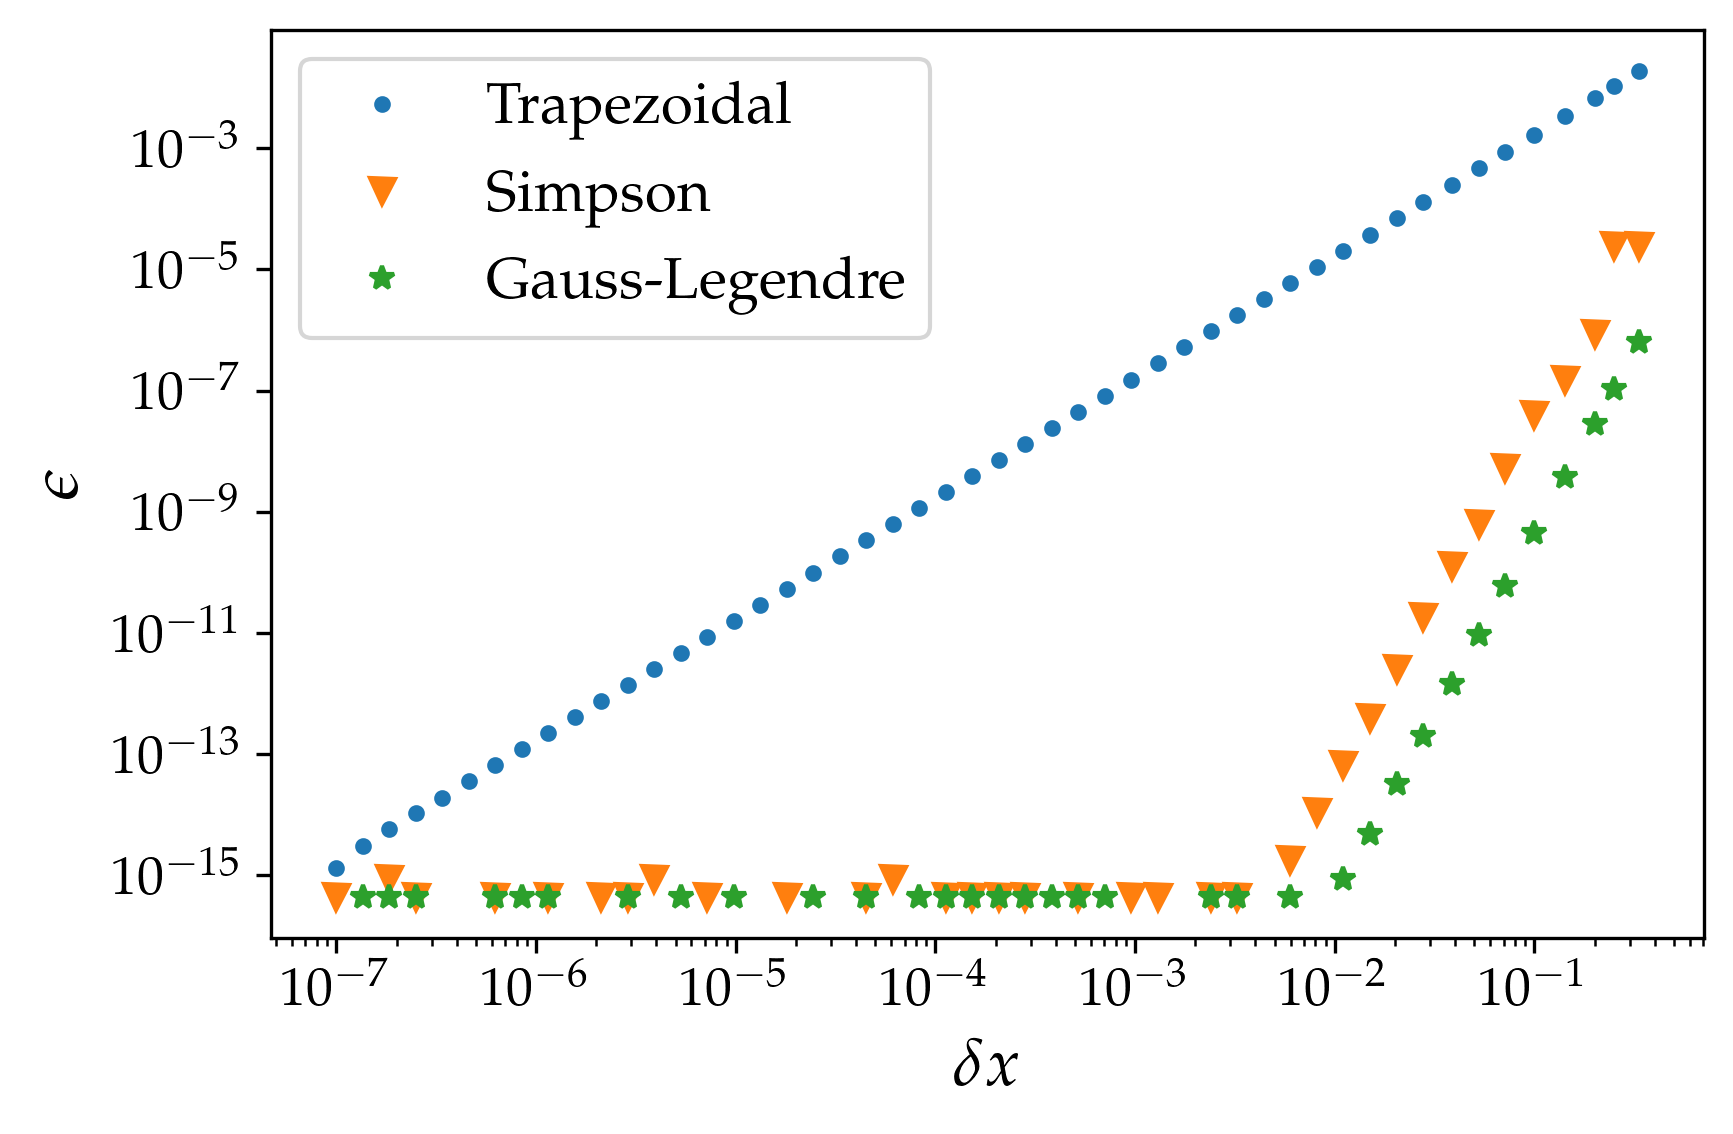

In [125]:
# Params
dx_span = np.logspace(-7, -0.5, 50)
true_dx_ls = [[],[],[]]

eps = 1e-14 
error = [[], [], []]

for dx_ in dx_span:
    for i in range(3):
        gr_spec = [['Trapezoidal', '.', trapezoidal], 
                [ 'Simpson', 'v', Simpson],
                [ 'Gauss-Legendre', '*', Gauss_Leg]]
        
        f_int = gr_spec[i][2]
        res = f_int(func, a, b, dx=dx_, r_true_dx=True)
        true_dx_ls[i].append(res[1])
        err = np.abs(res[0] - true)
        error[i].append(err)
true_dx = np.array(true_dx_ls)

error = np.array(error)
N_span = ((b-a) / true_dx)

N_span = N_span[0]

plt.figure(figsize=(6,4))
for i in range(3):
    plt.loglog(true_dx[0], error[i], ls='', marker=gr_spec[i][1], label=gr_spec[i][0])

plt.xlabel(r'$\delta x$')
plt.ylabel(r'$\epsilon$')
plt.legend()
plt.tight_layout()
plt.savefig('plots/conf_3mth')
plt.show()


dof = 47

a = 2.00e+00 +/- 7.583e-02
b = -7.79e-01 +/- 3.134e-01

Chi2 = 0.00
p-val = 1.00


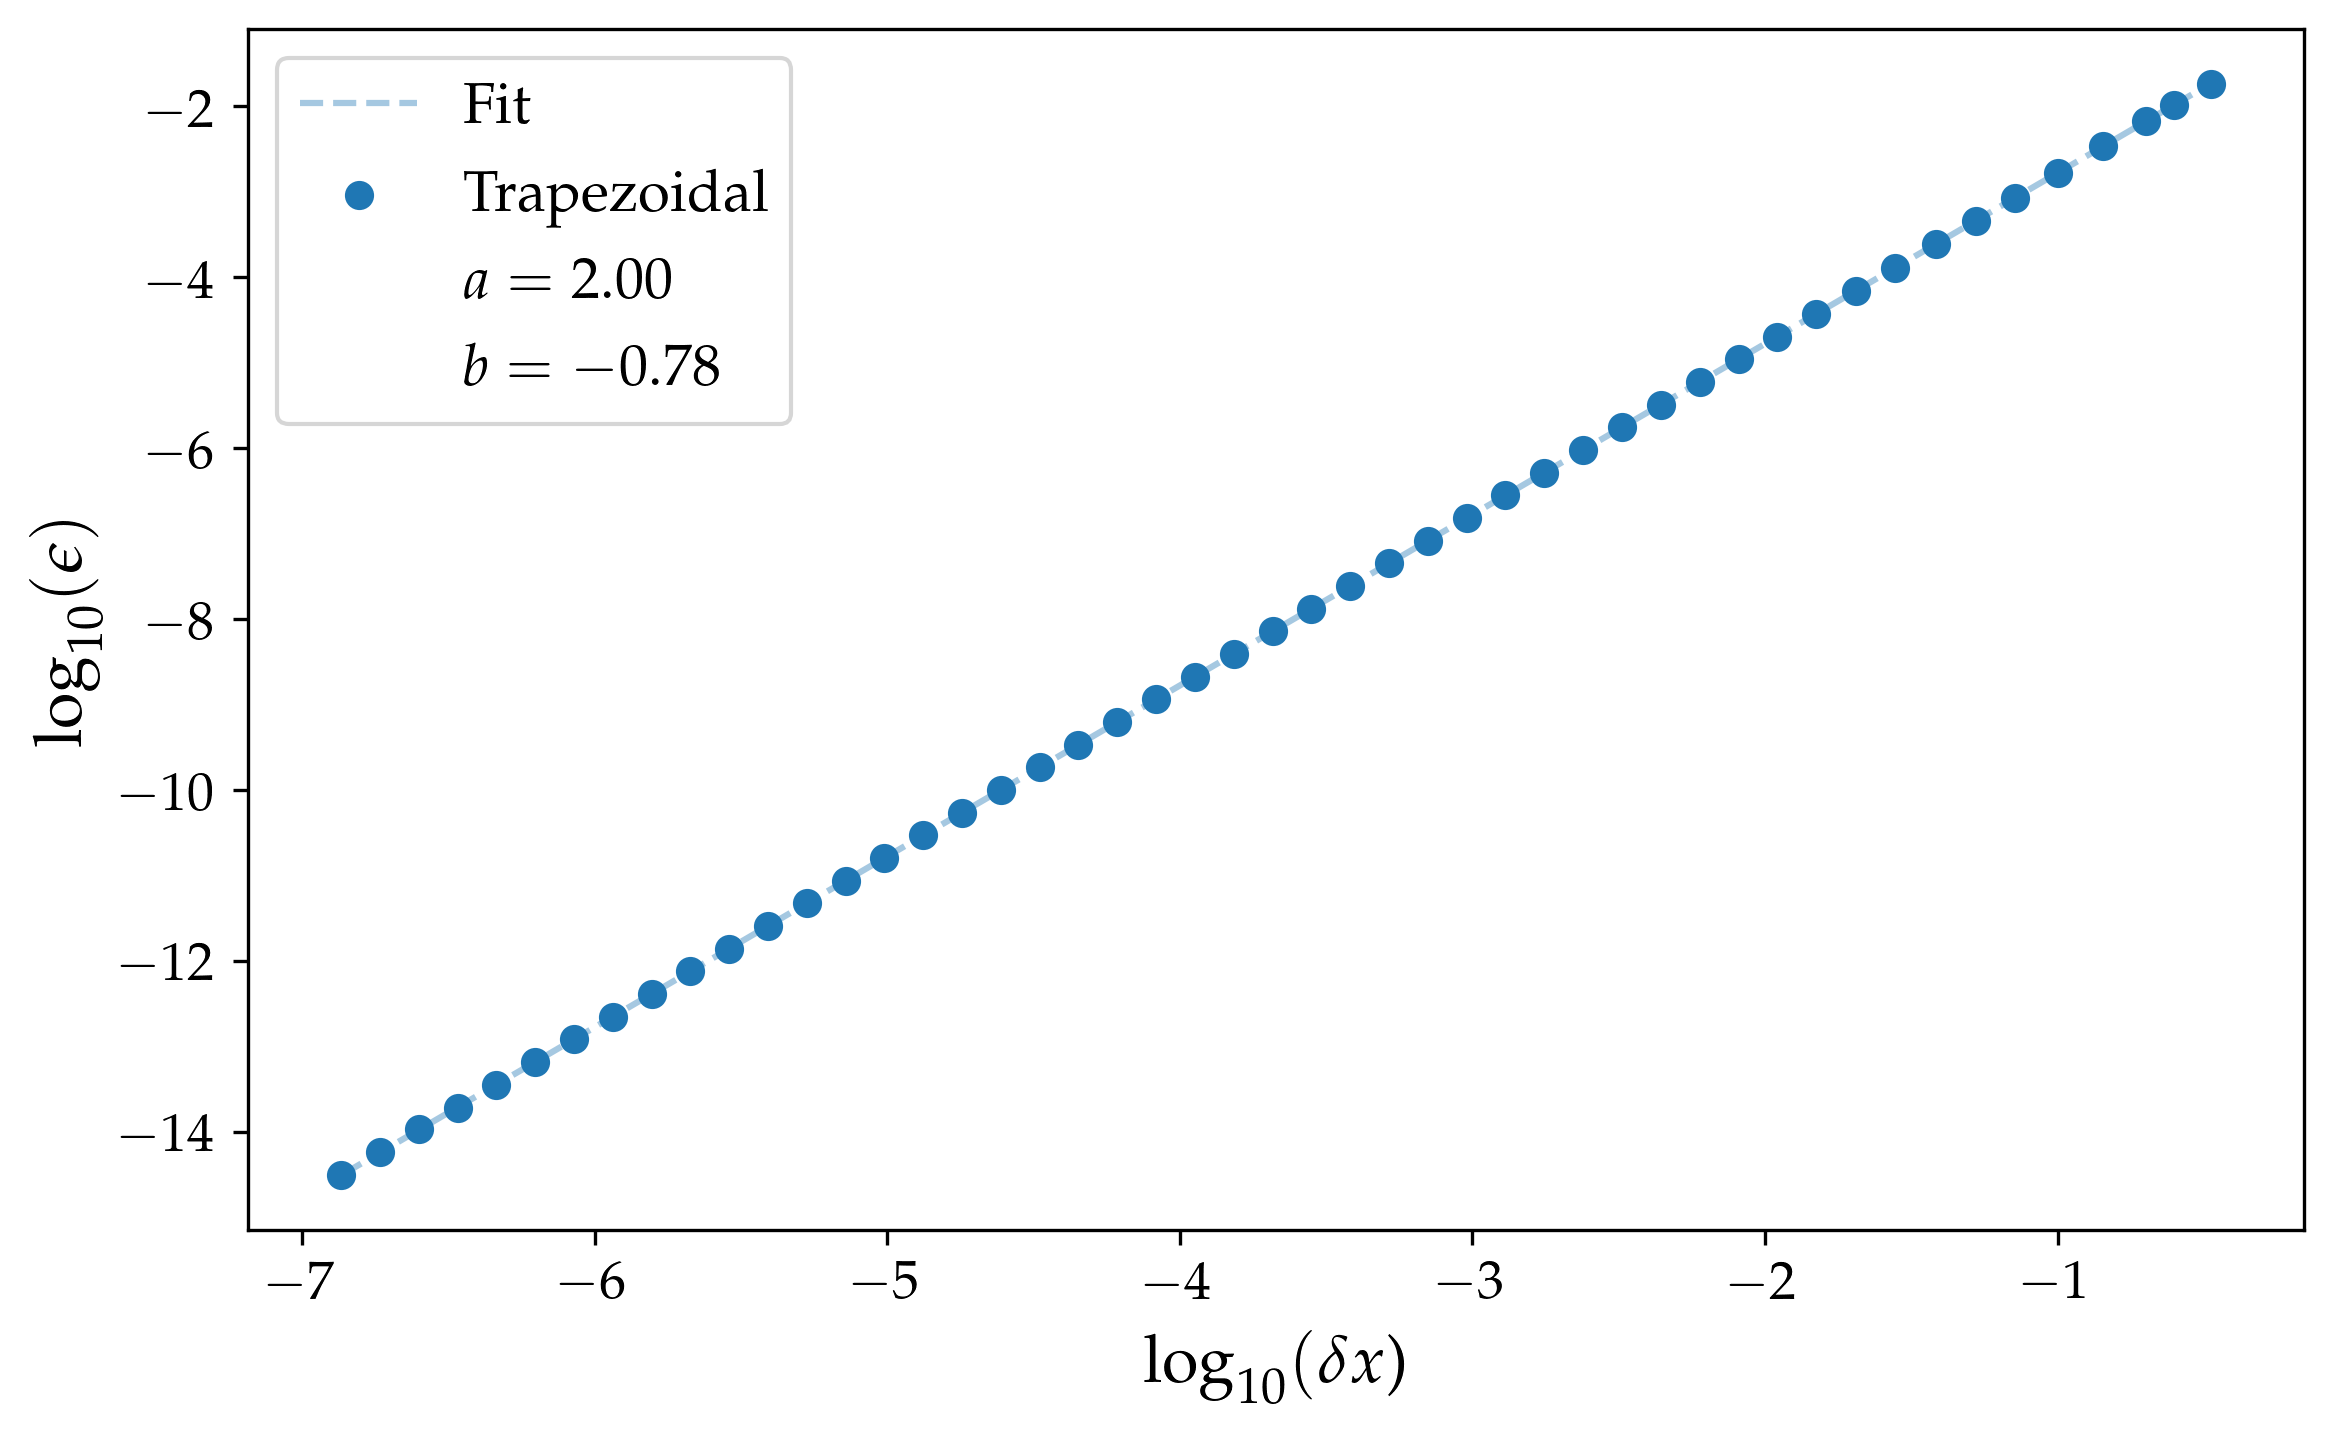

In [126]:
i = 0 
cut = 1
dx, eps_dx = (true_dx[i][cut:], error[i][cut:])

res_t = lin_fit(np.log10(dx), np.log10(eps_dx),
        mar='o', col='C0', name_points='Trapezoidal',
        labels=(r'$\log_{10}(\delta x$)', r'$\log_{10}(\epsilon)$'), save_name='plots/FitTrap_2')

dof = 8

a = 6.29e+00 +/- 8.584e-01
b = -1.00e+00 +/- 9.961e-01

Chi2 = 0.13
p-val = 1.00


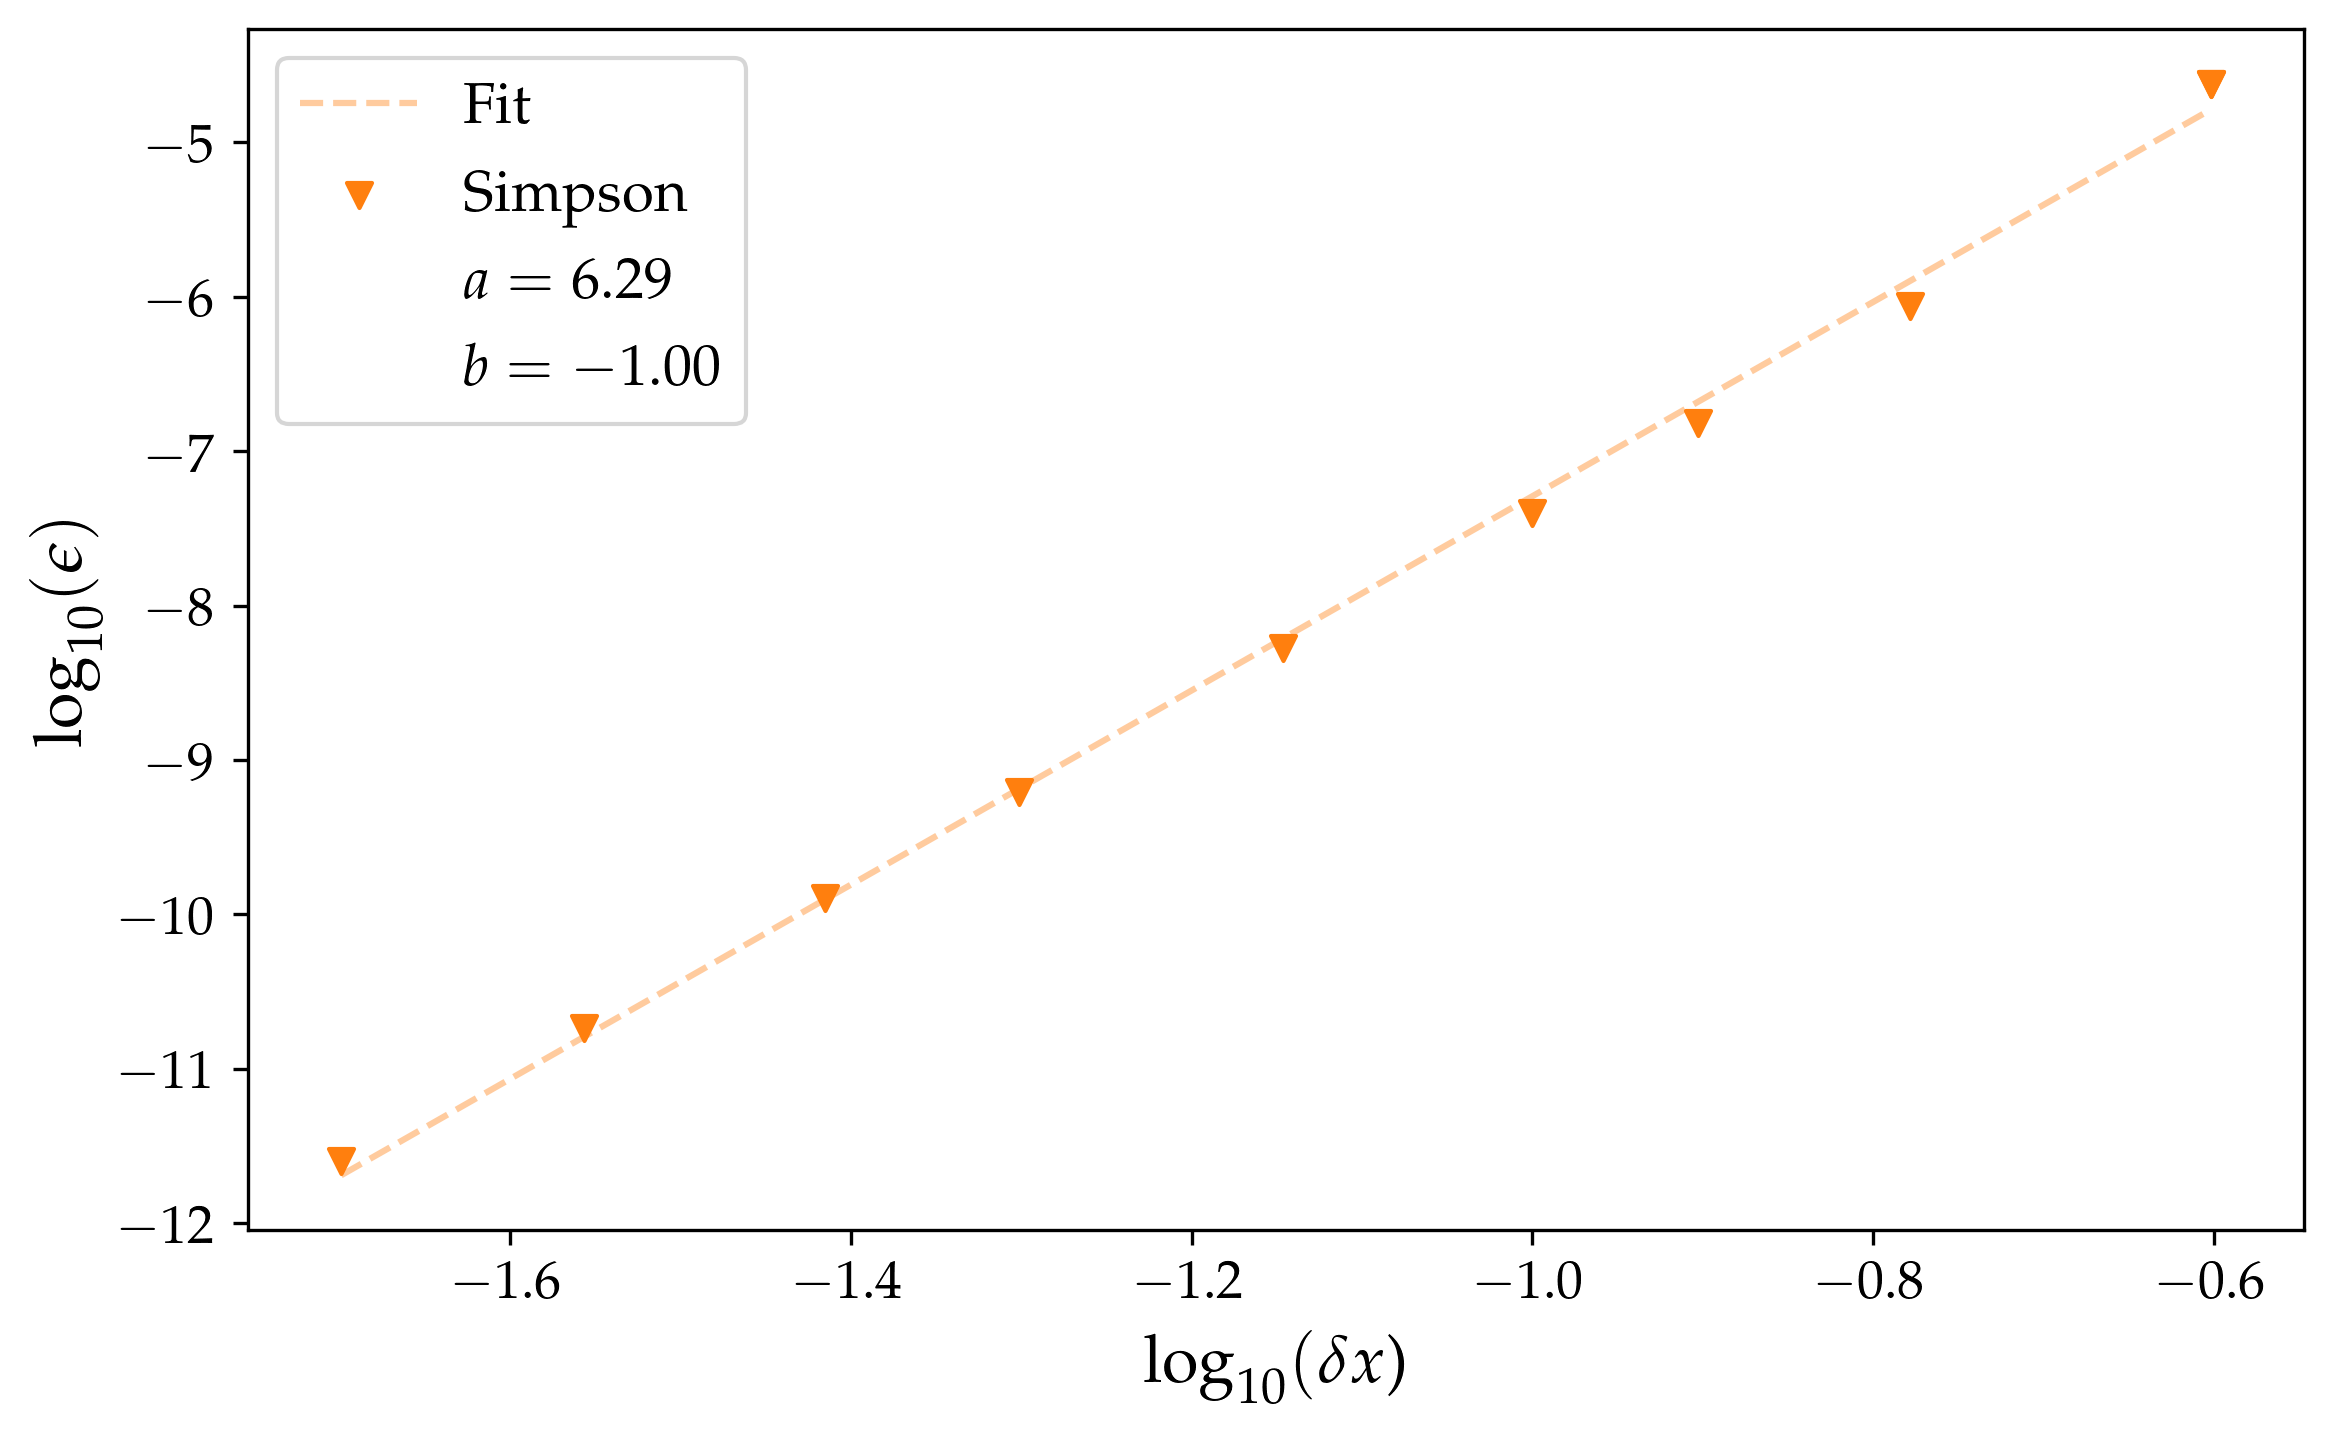

In [127]:
i = 1
cut = 40
dx, eps_dx = (true_dx[i][cut:], error[i][cut:])

res_s = lin_fit(np.log10(dx), np.log10(eps_dx),
        mar='v', col='C1', name_points='Simpson',
        labels=(r'$\log_{10}(\delta x$)', r'$\log_{10}(\epsilon)$'), save_name='plots/FitSimp_2')

dof = 8

a = 6.00e+00 +/- 8.024e-01
b = -3.35e+00 +/- 9.157e-01

Chi2 = 0.00
p-val = 1.00


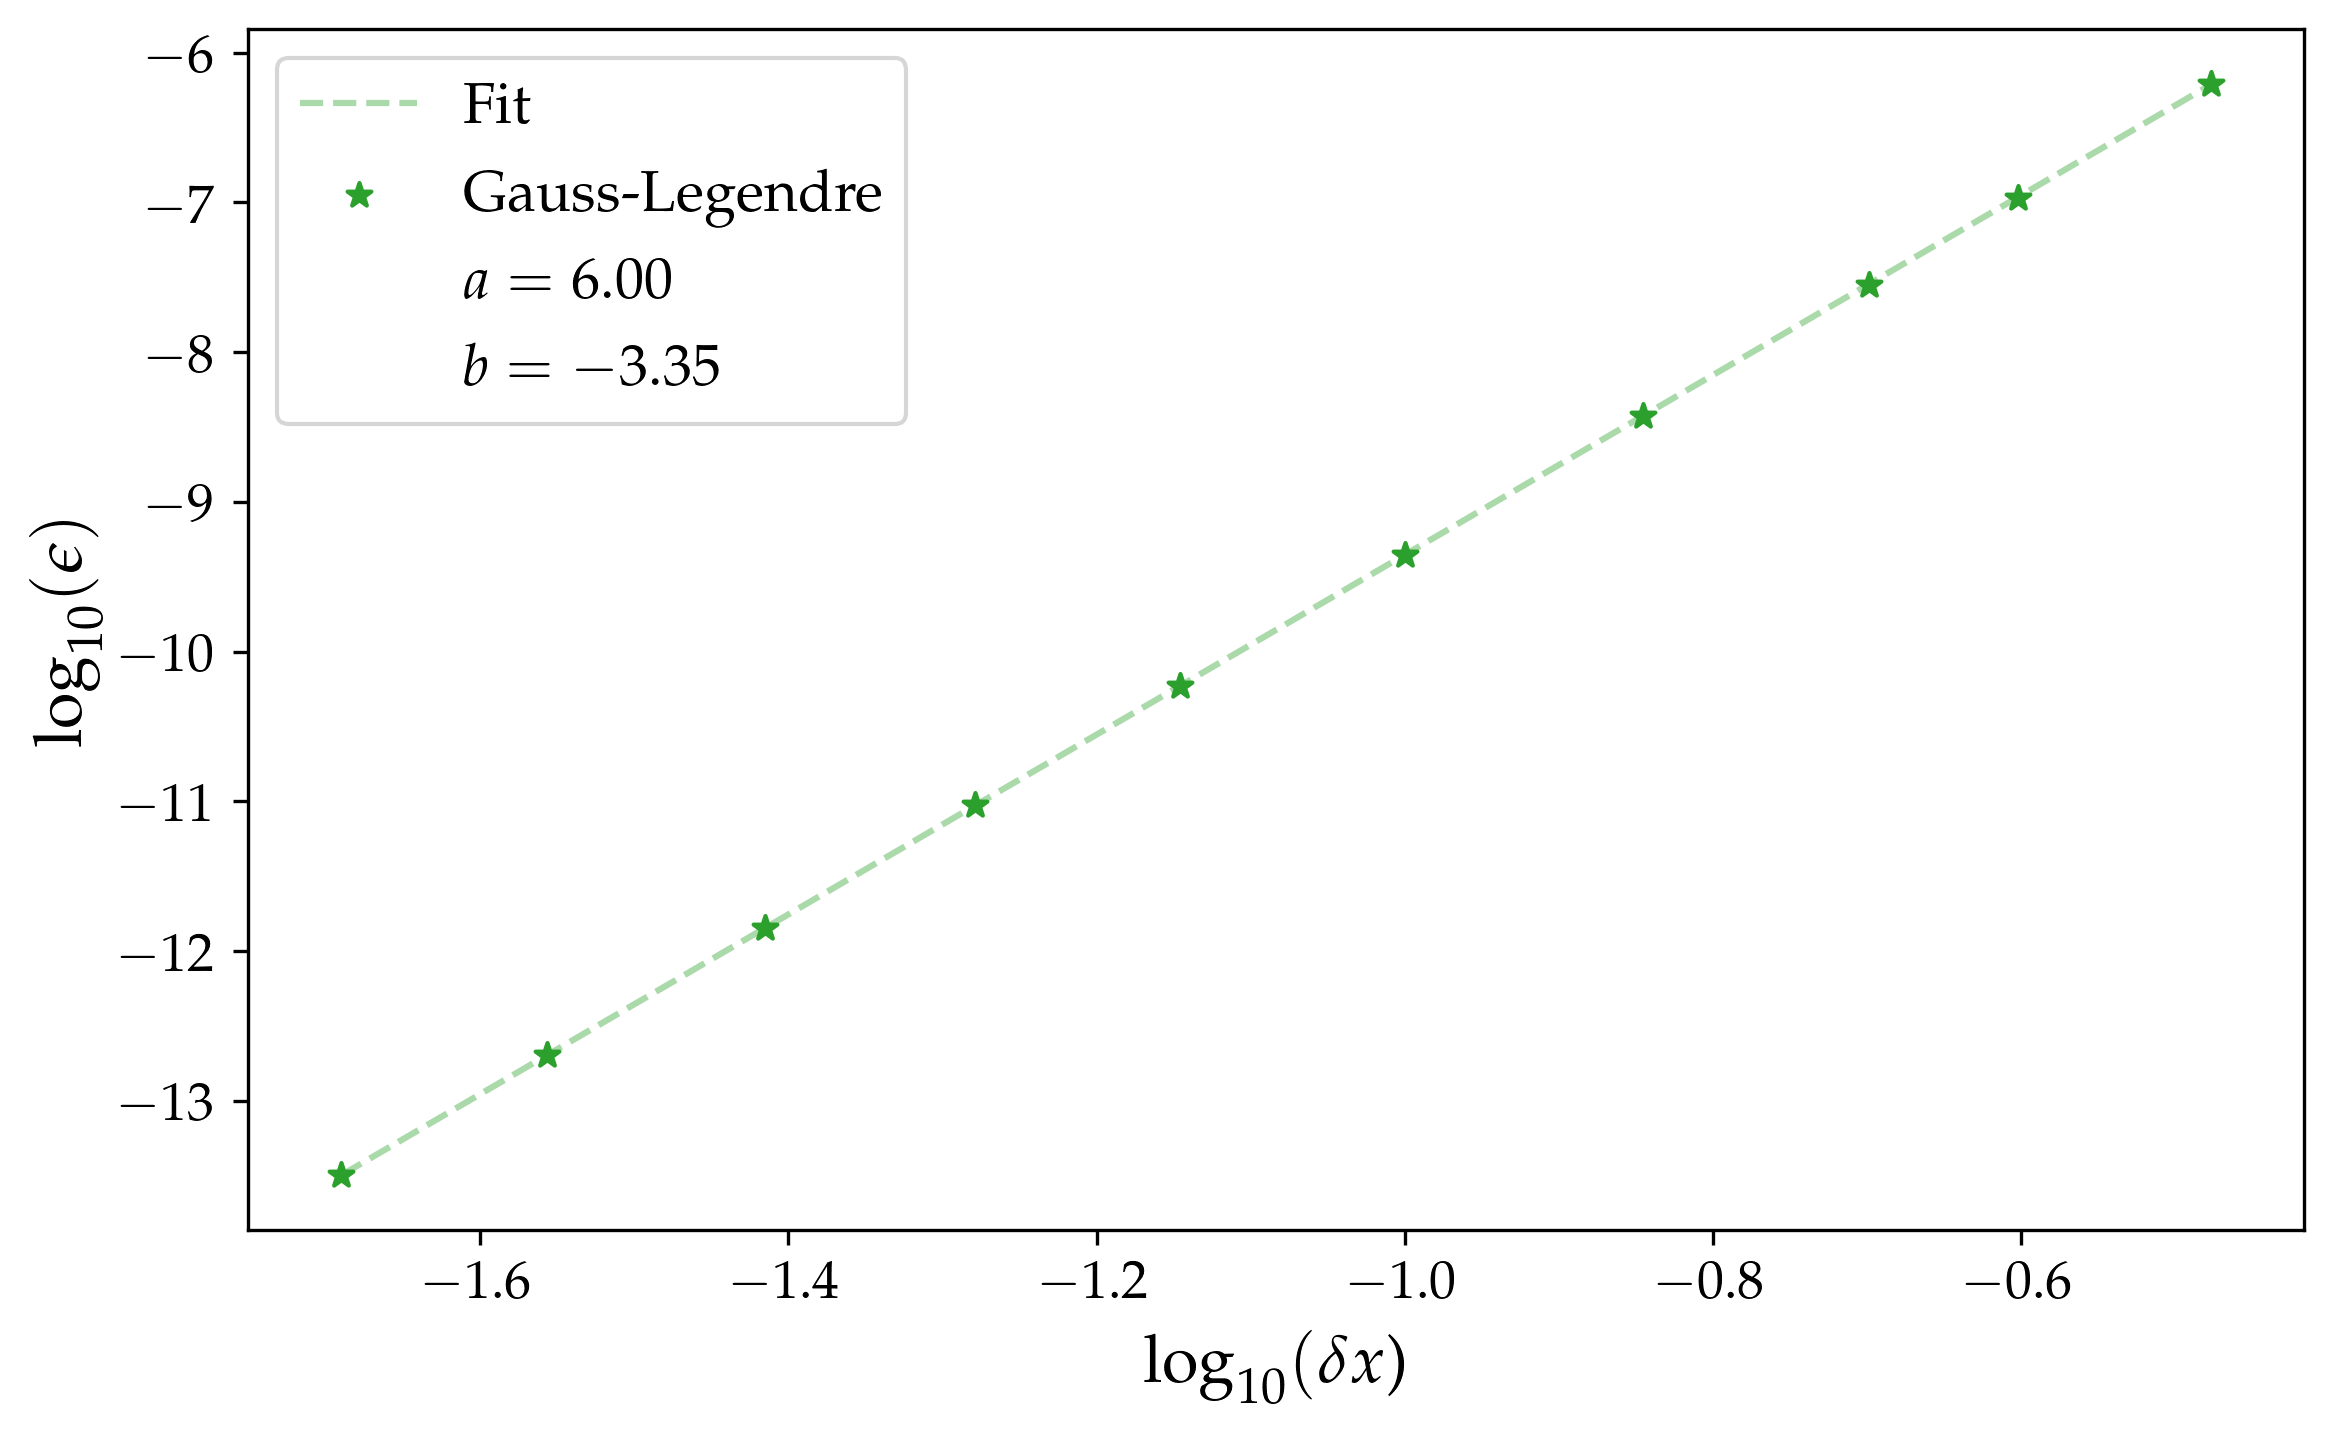

In [128]:
i = 2
cut = 40
dx, eps_dx = (true_dx[i][cut:], error[i][cut:])

res_g = lin_fit(np.log10(dx), np.log10(eps_dx),
        mar='*', col='C2', name_points='Gauss-Legendre',
        labels=(r'$\log_{10}(\delta x$)', r'$\log_{10}(\epsilon)$'), save_name='plots/FitGauss_2')

In [129]:

p_t = round(res_t[0][0])
print('Expected = 2')
print(f'    p_t = {p_t}')

print()
p_s = round(res_s[0][0])
print('Expected = 4')
print(f'    p_s = {p_s}')

p_g = round(res_g[0][0])
print(f'    p_g = {p_g}')
print()

# symbolic derivs
import sympy as sp
x_s = sp.symbols('x_s')
f_s = 4 / (1 + x_s**2)
d2f_s = sp.diff(f_s, x_s, 2) 
d3f_s = sp.diff(f_s, x_s, 3) 
d4f_s = sp.diff(f_s, x_s, 4) 

d2f = sp.lambdify(x_s, d2f_s, 'numpy')
d3f = sp.lambdify(x_s, d3f_s, 'numpy')
d4f = sp.lambdify(x_s, d4f_s, 'numpy')

x_test = np.linspace(0, 1, 1000)

print('--------- test --------')
print()
print(f'd3f(1) - d3f(0) = ({d3f(1)}) - ({d3f(0)}) = {d3f(1) - d3f(0)}')
print()
print('--------- test --------')

print()


ks = [1/12, 1/96768, 1/136080]
Ms = [np.max(abs(d2f(x_test))), np.max(abs(d4f(x_test)))]
Ms.append(Ms[1])        # doesn't compute the function again

eval_N = lambda p, k, Mf: int(np.ceil((k*Mf / eps)**(1/p)))

eps = 1e-6
N_trap = eval_N(p_t, ks[0], Ms[0])
N_simp = eval_N(p_s, ks[1], Ms[1])
N_gaus = eval_N(p_g, ks[2], Ms[2])

if N_simp % 2 != 0:     # for Simp N must be even
    N_simp += 1

print('eps =', eps)
print(f'\nif Trapezoidal, p = {p_t:.1f}:')
print('     N =', N_trap)
print(f'\nif Simpson, p = {p_s:.1f}:')
print('     N =', N_simp)
print(f'\nif Gauss-Legendre, p = {p_g:.1f}:')
print('     N =', N_gaus)

Expected = 2
    p_t = 2

Expected = 4
    p_s = 6
    p_g = 6

--------- test --------

d3f(1) - d3f(0) = (-0.0) - (-0.0) = 0.0

--------- test --------

eps = 1e-06

if Trapezoidal, p = 2.0:
     N = 817

if Simpson, p = 6.0:
     N = 4

if Gauss-Legendre, p = 6.0:
     N = 3


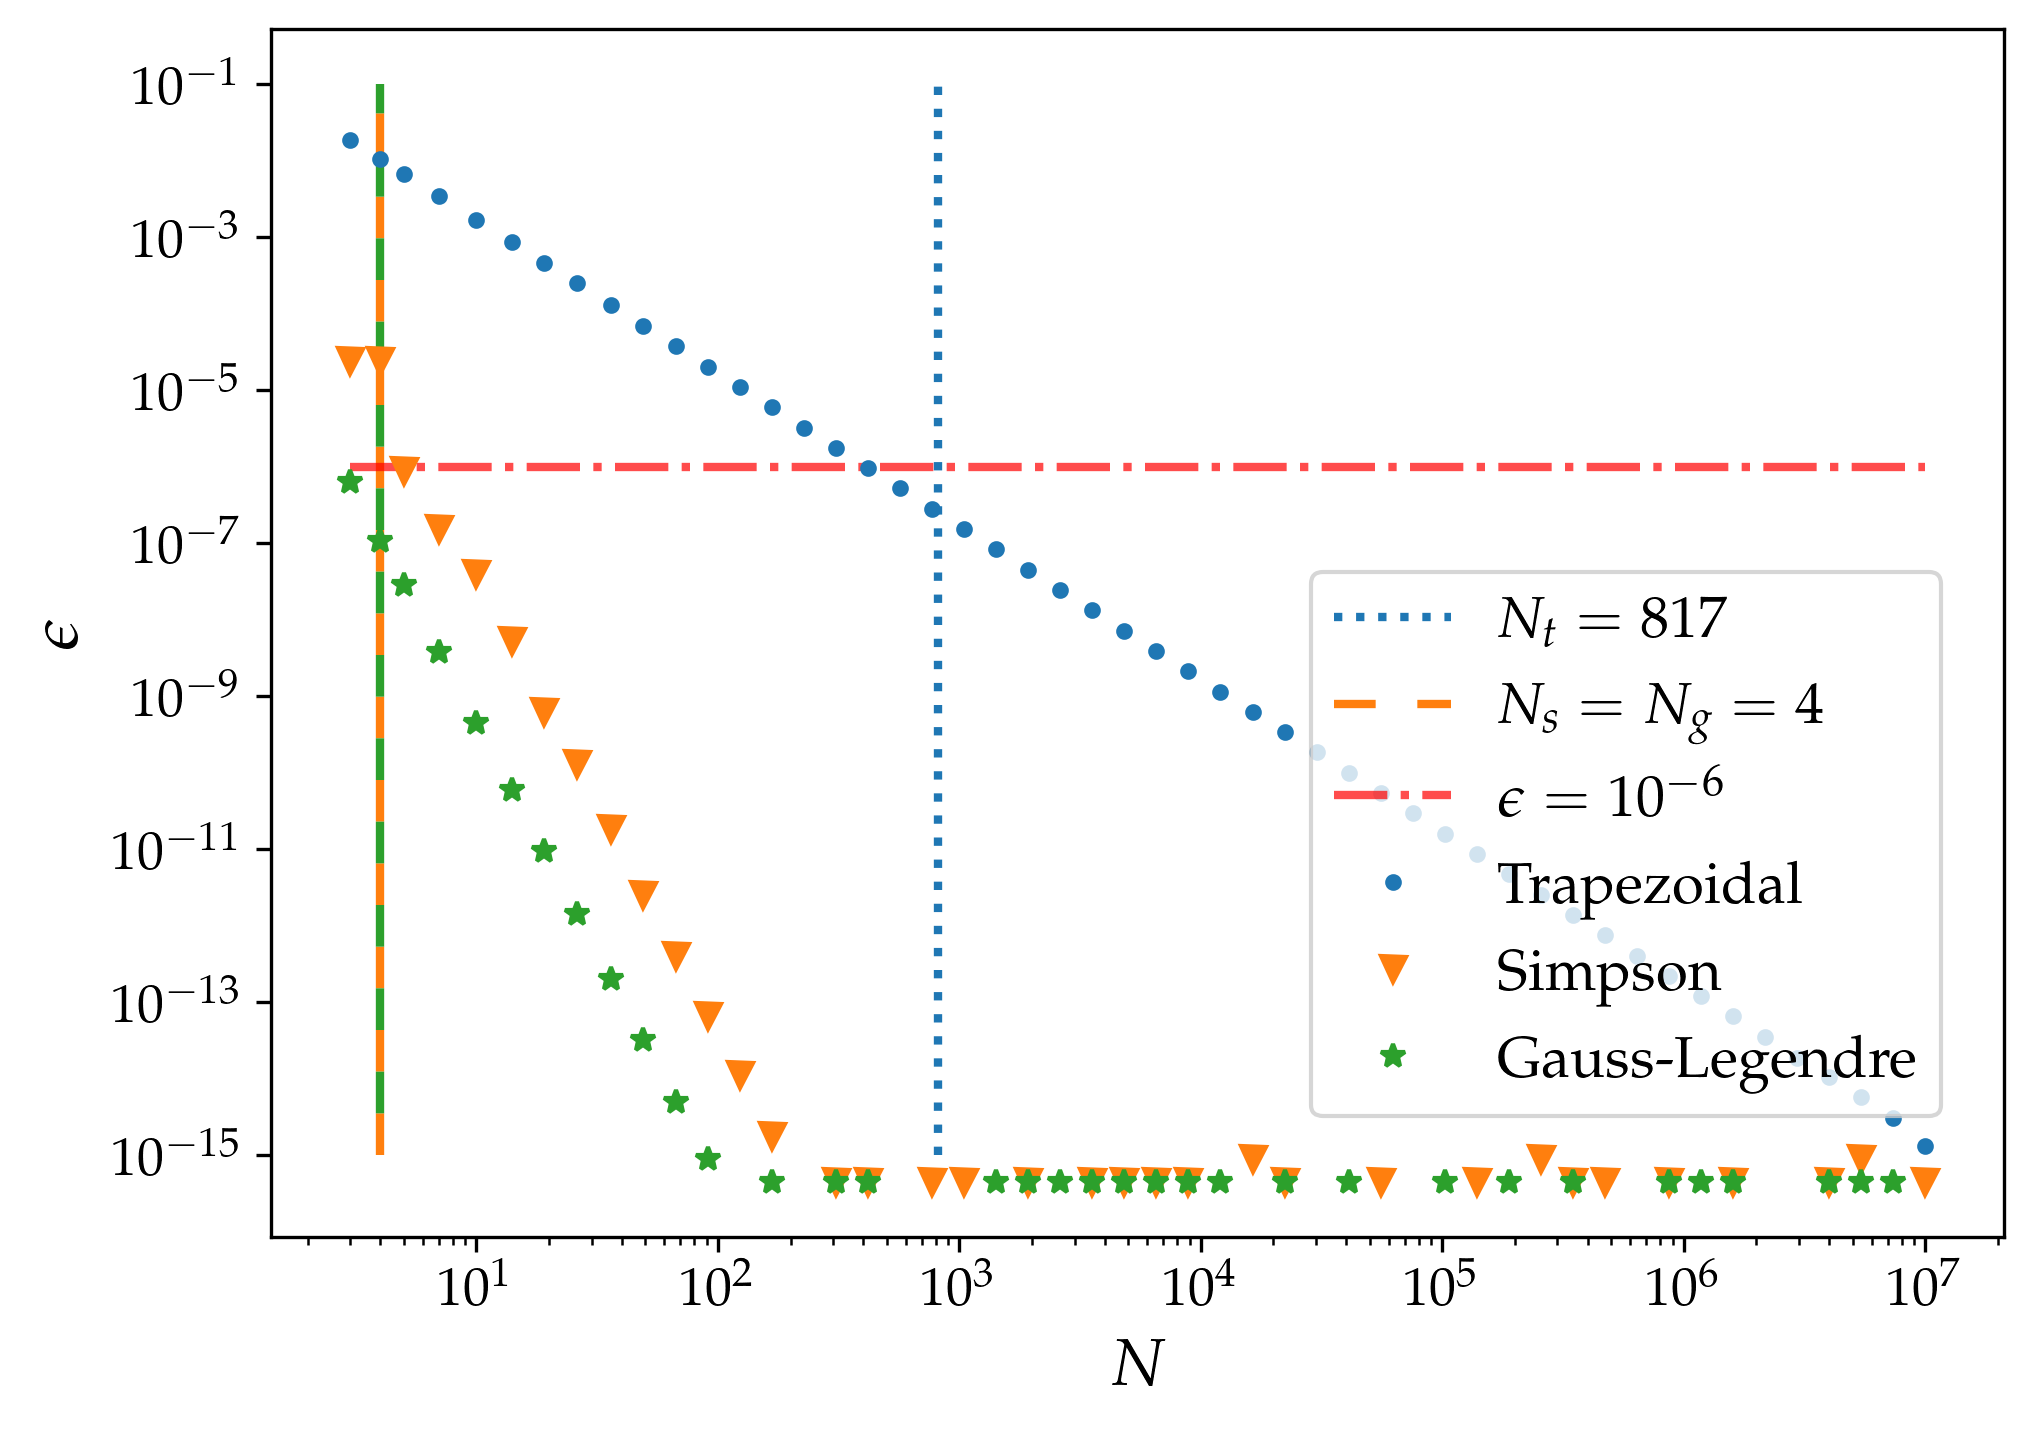

In [130]:
plt.figure(figsize=(7,5))

# N_2
plt.vlines(N_trap, 1e-15, 1e-1, color='C0', ls=':', lw=2,
            label=rf'$N_t = {N_trap:.0f}$')

# N_4
len_dash = 5
ax = plt.gca()
vl1 = plt.vlines(N_simp, 1e-15, 1e-1, color='C1', lw=2, 
                 linestyle=(0, (len_dash, len_dash)),
                 label=rf'$N_s = N_g = {N_simp:.0f}$')
vl2 = plt.vlines(N_simp, 1e-15, 1e-1, color='C2', lw=2, 
                 linestyle=(len_dash, (len_dash, len_dash)))

# epsilon
plt.hlines(eps, np.min(N_span), np.max(N_span), color='red', ls='-.',
            alpha=0.7, lw=2, label=r'$\epsilon=10^{-6}$')

for i in range(3):
    plt.loglog(N_span, error[i], ls='', marker=gr_spec[i][1], label=gr_spec[i][0])

plt.xlabel(r'$N$')
plt.ylabel(r'$\epsilon$')
plt.legend(loc=(0.6, 0.1))

plt.tight_layout()
plt.savefig('plots/check_prev')
plt.show()

